# Proyecto: Regresión Bayesiana Robusta

## Objetivo general

El objetivo de este proyecto es construir y comparar modelos de regresión robusta utilizando enfoques bayesianos.

Los estudiantes deberán implementar modelos robustos en NumPyro y analizar su comportamiento en presencia de:

- outliers,
- observaciones extremas,
- ruido no Gaussiano,
- distribuciones con colas pesadas.

El proyecto busca integrar:

- inferencia bayesiana,
- regresión robusta,
- regularización,
- métodos MCMC,
- y análisis de sensibilidad a outliers.

---

# Notación

- $y_i$ representa la variable respuesta.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes de regresión.
- $\mu_i$ representa la media condicional.
- $\sigma$ representa un parámetro de escala.
- $b$ representa el parámetro de escala Laplace.
- $\nu$ representa los grados de libertad.
- $\tau$ es el hyperparámetro de regularización.
- $X$ representa la matriz de diseño.
- $n$ es el número de observaciones.
- $p$ es el número de covariables.

---

# 1. Regresión lineal clásica

La regresión lineal tradicional asume:

$$
y_i
=
x_i^T\beta
+
\varepsilon_i
$$

con:

$$
\varepsilon_i
\sim
\mathcal{N}(0,\sigma^2)
$$

Sin embargo, este modelo puede ser muy sensible a observaciones extremas.

---

# 2. Problema de outliers

Cuando existen:

- errores extremos,
- ruido pesado,
- observaciones atípicas,

el modelo Gaussiano puede:

- producir estimaciones sesgadas,
- generar inferencia inestable,
- deteriorar capacidad predictiva.

Por ello se utilizan modelos robustos.

---

# 3. Regresión Laplace

El primer enfoque robusto utiliza errores Laplace:

$$
y_i
\sim
\text{Laplace}(\mu_i,b)
$$

donde:

$$
\mu_i
=
x_i^T\beta
$$

La distribución Laplace posee:

- colas más pesadas que la Normal,
- mayor robustez frente a outliers.

---

# 4. Interpretación de la distribución Laplace

La distribución Laplace:

- penaliza menos observaciones extremas,
- reduce sensibilidad a errores grandes,
- produce estimadores más robustos.

Además, se relaciona con pérdidas tipo $L_1$.

---

# 5. Regresión con distribución t de Student

El segundo enfoque robusto utiliza:

$$
y_i
\sim
t_{\nu}(\mu_i,\sigma)
$$

donde:

- $\mu_i = x_i^T\beta$,
- $\sigma$ es el parámetro de escala,
- $\nu$ representa los grados de libertad.

---

# 6. Grados de libertad

El parámetro:

$$
\nu > 2
$$

controla el grosor de las colas.

Interpretación:

- $\nu$ pequeño:
  - colas muy pesadas,
  - alta robustez frente a outliers.

- $\nu$ grande:
  - comportamiento cercano a Normal.

Esto permite que el modelo aprenda automáticamente el nivel de robustez necesario.

---

# 7. Priors Bayesianos

Los coeficientes utilizan:

$$
\beta_j
\sim
\mathcal{N}(0,\tau^2)
$$

con:

$$
\tau
\sim
\text{HalfNormal}(1)
$$

Asimismo:

$$
\sigma
\sim
\text{HalfNormal}(1)
$$

y:

$$
b
\sim
\text{HalfNormal}(10)
$$

Estos priors inducen regularización y controlan dispersión.

---

# 8. Inferencia Bayesiana

El objetivo es aproximar la distribución posterior:

$$
p(\beta,\tau,\sigma,\nu \mid X,y)
$$

utilizando:

- Markov Chain Monte Carlo (MCMC),
- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El resultado final consiste en muestras posteriores de los parámetros y distribuciones predictivas.

---

# 9. Validación Cruzada

La comparación entre modelos robustos se realizará mediante validación cruzada.

En cada fold:

1. se ajusta el modelo,
2. se generan muestras posteriores,
3. se evalúa desempeño fuera de muestra.

---

# 10. Métrica de evaluación

La métrica principal será el Negative Log-Likelihood (NLL):

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor desempeño predictivo,
  - mejor robustez,
  - mejor calibración probabilística.

- mayor NLL:
  - peor capacidad predictiva.

---

# 11. Comparación entre modelos robustos

Los estudiantes deberán comparar:

---

## Modelo Laplace

Ventajas:

- implementación sencilla,
- robustez moderada,
- relación con pérdidas $L_1$.

---

## Modelo t-Student

Ventajas:

- colas adaptativas,
- robustez flexible,
- mejor modelación de outliers extremos.

Desventajas:

- mayor complejidad inferencial.

---

# 12. Visualización y análisis posterior

Los estudiantes deberán analizar:

- distribuciones posteriores de coeficientes,
- incertidumbre posterior,
- comportamiento de $\nu$,
- sensibilidad a outliers,
- estabilidad predictiva,
- comparación entre modelos.

También deberán visualizar:

- densidades posteriores,
- distribuciones predictivas,
- residuos,
- observaciones extremas.

---

# 13. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un dataset real de regresión.
2. Analizar presencia de outliers.
3. Implementar modelos robustos bayesianos.
4. Ajustar modelos mediante NUTS.
5. Analizar convergencia MCMC.
6. Comparar desempeño predictivo.
7. Evaluar robustez frente a observaciones extremas.
8. Interpretar parámetros posteriores.
9. Elaborar conclusiones estadísticas.

---

# 14. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación de modelos,
- métricas de evaluación,
- visualizaciones posteriores,
- análisis de outliers,
- interpretación estadística,
- conclusiones.

In [1]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import jax.random as random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, ParameterSampler, KFold
from scipy.stats import distributions as scdist
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

numpyro.set_host_device_count(3)
plt.style.use("ggplot")

# **Conjunto de datos**

En el proyecto pueden usar datos simulados para ilustrar, pero también utilicen datos reales para resolver un problema de aprendizaje no supervisado. Realicen el debido preprocesamiento de datos que han aprendido en sus demás cursos antes de ajustar los modelos: escaladores, métodos de reducción de dimensión con PCA, entre otros.

In [2]:
n = 2000
p = 5


np.random.seed(10)
X = np.random.randn(n, p)
X = np.hstack((np.ones((n,1)), X))  # intercepto

beta_true = np.array([1.0, 2.0, -1.5, 0.0, 1.2, -0.5])


mu = X @ beta_true



noise = 0.5 * np.random.randn(n)



outlier_idx = np.random.choice(n, size=int(0.05*n), replace=False)

noise[outlier_idx] += np.random.normal(0, 20, size=len(outlier_idx))

y = mu + noise



X = jnp.array(X)
y = jnp.array(y)

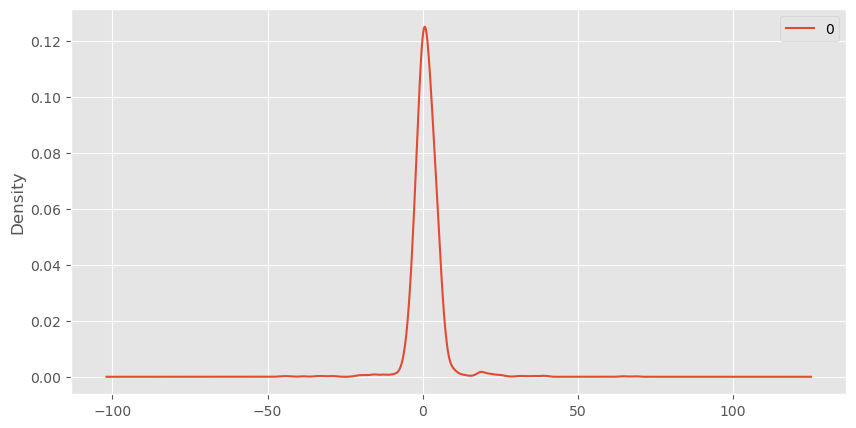

In [3]:
pd.DataFrame(y).plot.kde(figsize = (10, 5))
plt.show()

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=18081997)

# **Regresión Lineal**

In [5]:
def ridge_lr_model(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    Beta = numpyro.sample("beta", dist.Normal(0., tau).expand([p]).to_event(1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(10.))

    mu = jnp.matmul(X, Beta)

    with numpyro.plate("data", n):

        numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

In [6]:
burn_in = 1500
num_samples = 2000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [7]:
def cv_nll_model(model, X, y, folds=10, seed=1):

    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    fold_nll = []

    progress_bar = tqdm(total=folds, desc="Cross Validation")

    for fold, (train_indx, valid_indx) in enumerate(kf.split(X)):

        X_train, X_valid = X[train_indx], X[valid_indx]
        y_train, y_valid = y[train_indx], y[valid_indx]

        rng_key = random.PRNGKey(seed + fold)

        kernel = NUTS(model)

        mcmc = MCMC(kernel,
                        num_samples=num_samples,
                        num_chains=num_chains,
                        num_warmup=burn_in,
                        chain_method=chain_method,
                        progress_bar=False)

        mcmc.run(rng_key, X_train, y_train)

        posterior_samples = mcmc.get_samples()

        nll = -log_likelihood(model, posterior_samples, X_valid, y_valid)["y"].mean(axis=1).mean().item()

        fold_nll.append(nll)

        progress_bar.update(1)
        progress_bar.set_postfix({
            "fold": fold,
            "nll": f"{nll:.4f}"
            })


    progress_bar.close()

    return fold_nll

In [8]:
results_nll = cv_nll_model(ridge_lr_model, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [00:23<00:00,  2.38s/it, fold=9, nll=2.7460]


In [9]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 3.0330039978027346
std nll: 0.3409069200992985


# **Regresión Laplace**

In [10]:
def laplace_lr_model(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    Beta = numpyro.sample("beta", dist.Normal(0., tau).expand([p]).to_event(1))
    b = numpyro.sample("sigma", dist.HalfNormal(10.))

    mu = jnp.matmul(X, Beta)

    with numpyro.plate("data", n):

        numpyro.sample("y", dist.Laplace(mu, b), obs=y)

In [11]:
results_nll = cv_nll_model(laplace_lr_model, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [00:23<00:00,  2.32s/it, fold=9, nll=1.7181]


In [12]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 1.9198532104492188
std nll: 0.23308093316307346


# **Regresión t-Student**

In [13]:
def TStudent_model(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    beta = numpyro.sample("beta", dist.Normal(0.0, tau).expand([p]).to_event(1))

    nu = numpyro.sample("nu", dist.HalfNormal(1.0)) + 2

    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))

    mu = jnp.matmul(X, beta)

    with numpyro.plate("data", n):

        numpyro.sample("y", dist.StudentT(df=nu, loc=mu, scale=sigma), obs=y)

In [14]:
results_nll = cv_nll_model(TStudent_model, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [00:32<00:00,  3.26s/it, fold=9, nll=1.1491]


In [15]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 1.244298791885376
std nll: 0.12424783027652272


# **Mejor modelo**

In [16]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(TStudent_model)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=False)

mcmc.run(rng_key, X_train, y_train)

In [17]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      1.00      0.01      1.00      0.98      1.02   8567.35      1.00
   beta[1]      2.01      0.01      2.01      1.99      2.03   8449.30      1.00
   beta[2]     -1.53      0.01     -1.53     -1.55     -1.50   8326.35      1.00
   beta[3]     -0.03      0.01     -0.03     -0.06     -0.01   7468.58      1.00
   beta[4]      1.18      0.01      1.18      1.16      1.20   8881.99      1.00
   beta[5]     -0.48      0.01     -0.48     -0.50     -0.46   8702.77      1.00
        nu      0.01      0.01      0.01      0.00      0.02   9700.34      1.00
     sigma      0.41      0.01      0.41      0.39      0.43   8185.65      1.00
       tau      1.27      0.33      1.22      0.75      1.76   7624.56      1.00

Number of divergences: 0


In [18]:
samples = mcmc.get_samples()

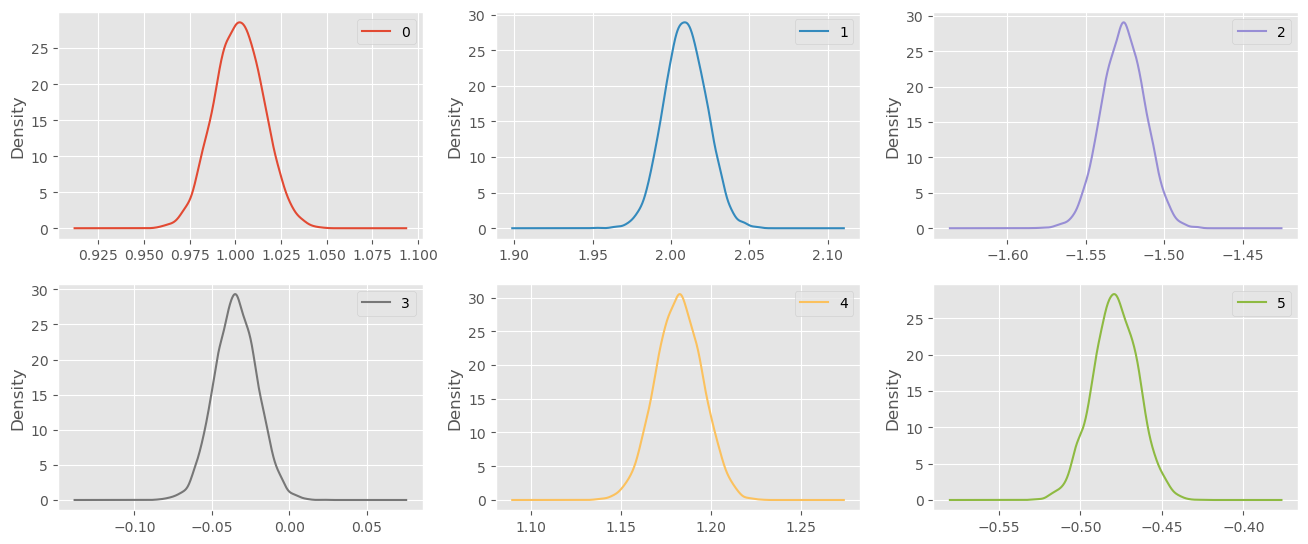

In [19]:
pd.DataFrame(samples["beta"]).plot.kde(subplots=True, layout=(3, 3), sharex=False, figsize=(16, 10))
plt.show()

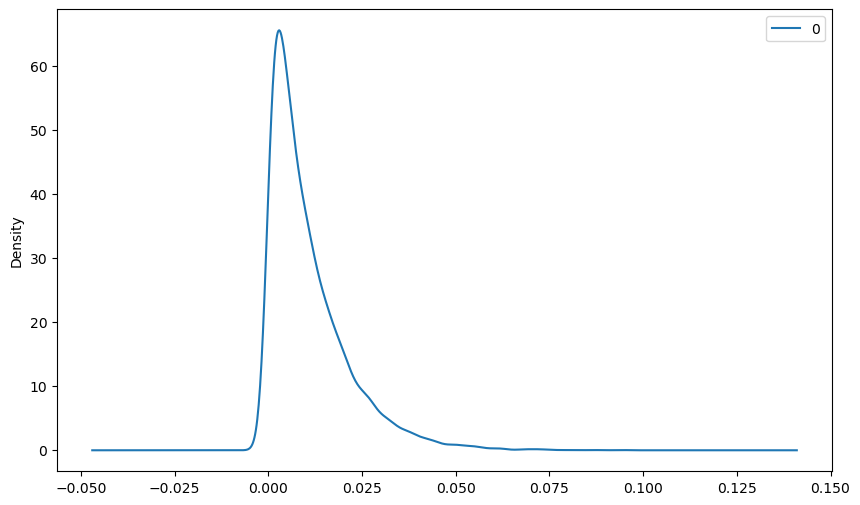

In [26]:
pd.DataFrame(samples["nu"]).plot.kde( figsize=(10, 6))
plt.show()

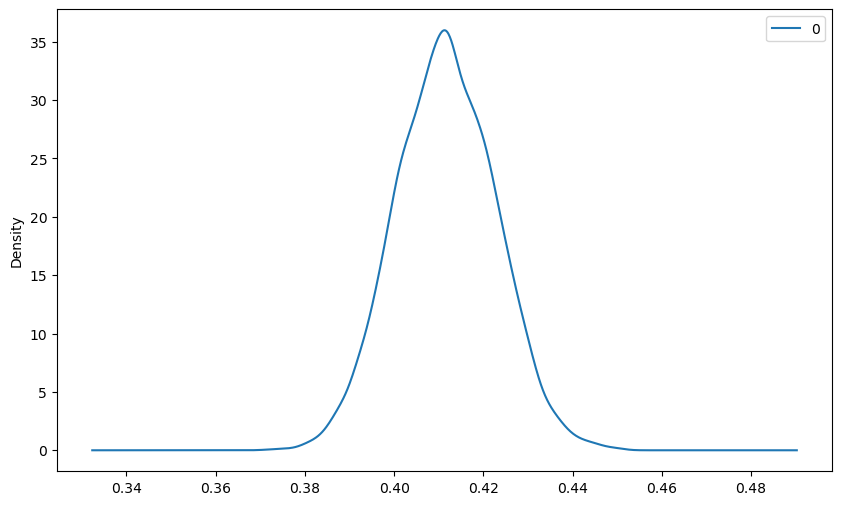

In [27]:
pd.DataFrame(samples["sigma"]).plot.kde( figsize=(10, 6))
plt.show()

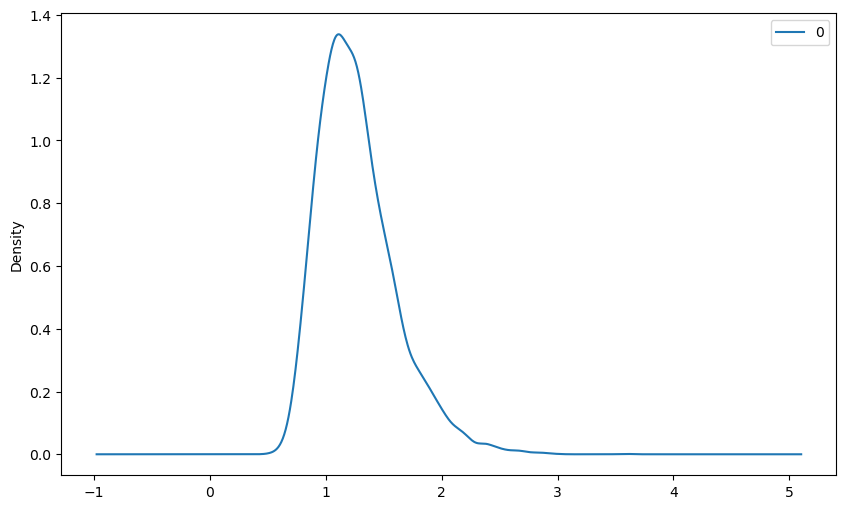

In [28]:
pd.DataFrame(samples["tau"]).plot.kde( figsize=(10, 6))
plt.show()

# **Distribución de algunas métricas**

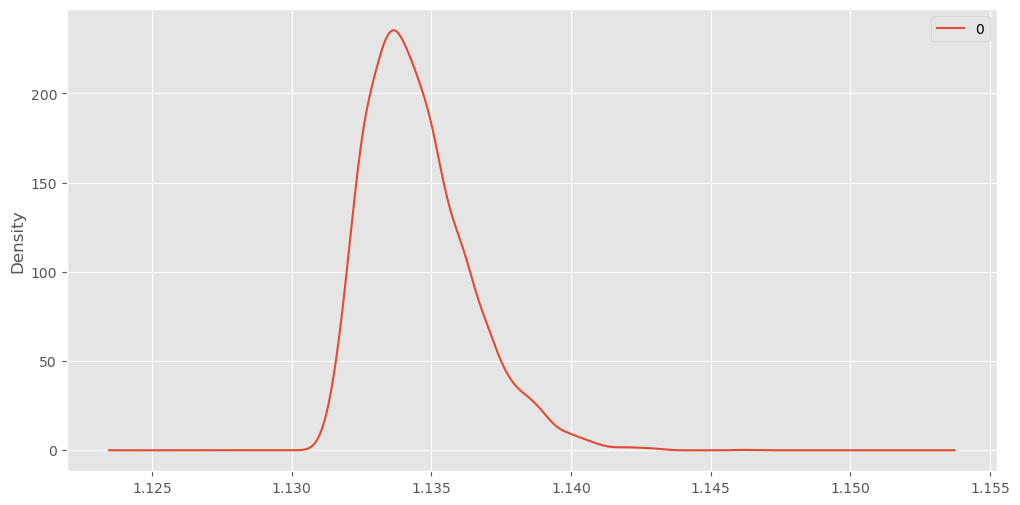

In [20]:
nll_samples = -log_likelihood(TStudent_model, samples, X_val, y_val)["y"].mean(axis=1)
pd.DataFrame(nll_samples).plot.kde(figsize=(12, 6))
plt.show()

In [22]:
y_pred_samples = jnp.matmul(samples["beta"], X_val.T)

mae_samples = jnp.abs(y_val[None, :] - y_pred_samples).mean(axis=1)

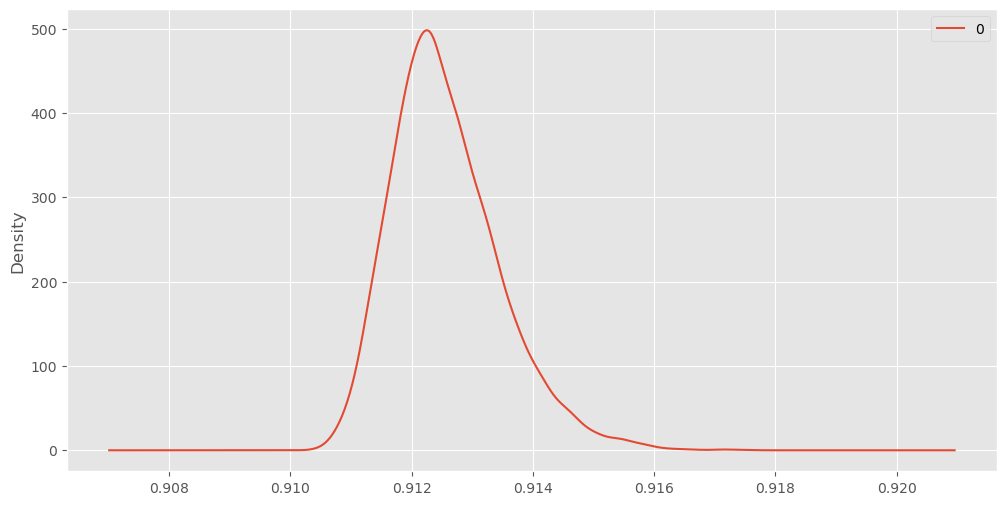

In [23]:
pd.DataFrame(mae_samples).plot.kde(figsize=(12, 6))
plt.show()

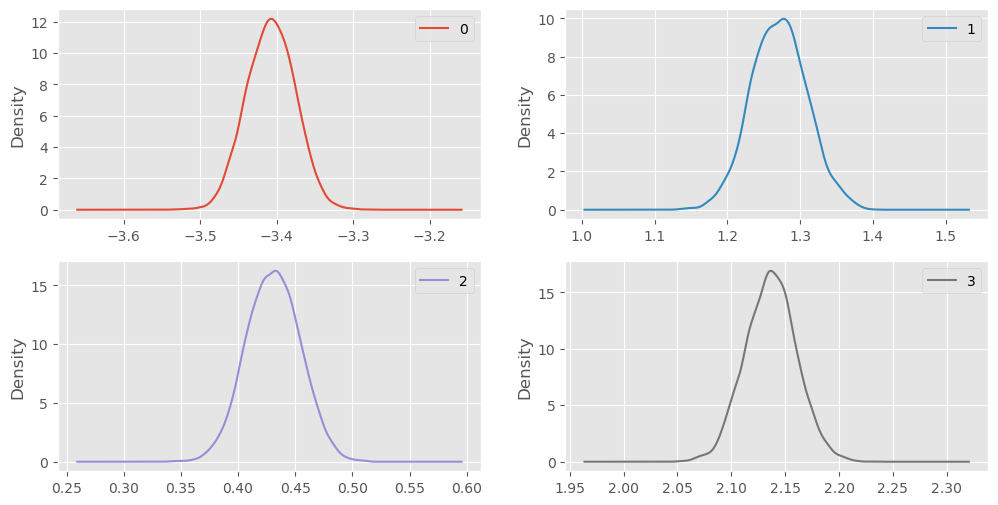

In [24]:
pd.DataFrame(y_pred_samples[:,:4]).plot.kde(figsize=(12, 6), subplots=True, layout=(2, 2), sharex=False)
plt.show()